In [17]:

# CÀI ĐẶT VÀ IMPORT THƯ VIỆN

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [18]:

#  KHAI BÁO THAM SỐ

# ĐƯỜNG DẪN DỮ LIỆU 
TRAIN_DIR = "/kaggle/input/ferpuls-balance-dataset/train" 
VAL_DIR = "/kaggle/input/ferpuls-balance-dataset/val"
TEST_DIR = "/kaggle/input/ferpuls-balance-dataset/test"
# Tham số Huấn luyện
NUM_CLASSES = 8  
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_WORKERS = 4
OUTPUT_DIR = './outputs'

# Cấu hình Thiết bị
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

Device: cuda


In [19]:
# --- Transform ---
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomResizedCrop(size=(75, 75), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((75, 75)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- Datasets và Loaders ---
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds = datasets.ImageFolder(VAL_DIR, transform=val_transform)
CLASSES = train_ds.classes
print("Classes:", CLASSES)
print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Classes: ['angry', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'suprise']
Train samples: 51776, Val samples: 12944


In [20]:
## 2.4. Trực quan hóa Dữ liệu
def visualize_data(dataloader, classes, num_samples=8):
    """Trực quan hóa một số mẫu từ dataloader."""
    data_iter = iter(dataloader)
    images, labels = next(data_iter)
    
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i + 1)
        img = images[i].numpy() / 2 + 0.5  # unnormalize
        img = np.transpose(img, (1, 2, 0)) # C, H, W -> H, W, C
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(classes[labels[i].item()])
        plt.axis('off')
    plt.suptitle("Augmented Training Samples", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


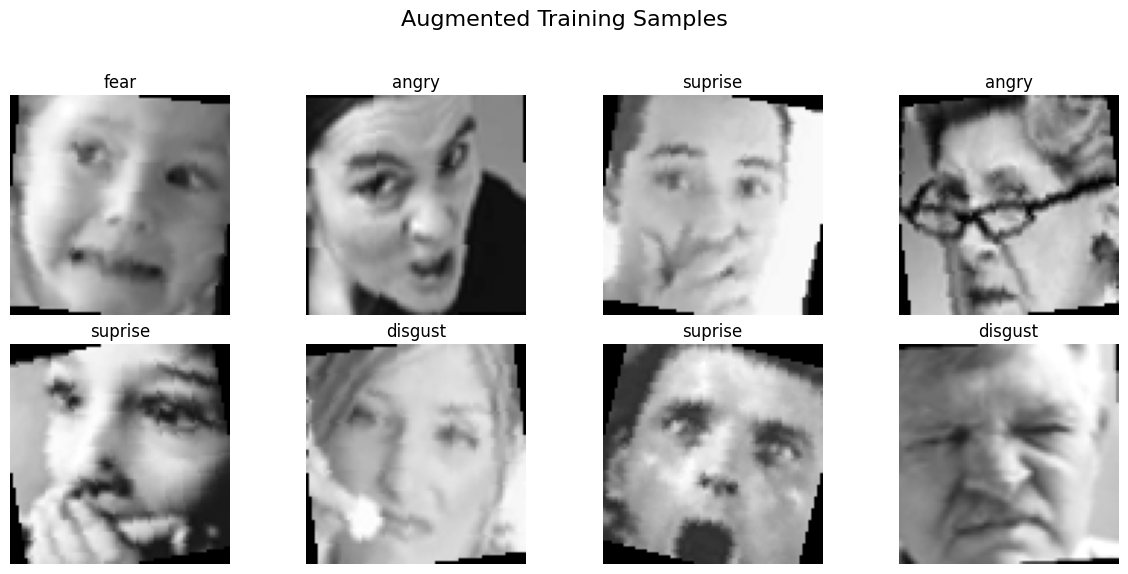

In [21]:
visualize_data(train_loader, CLASSES)

In [22]:

#  MODEL DEFINITION 

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity # Đường tắt Residual
        return self.relu(out)

class FaceEmotionCNN(nn.Module):
    def __init__(self, num_classes=7, in_channels=1):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.layer1 = nn.Sequential(ResidualBlock(64), ResidualBlock(64))
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResidualBlock(128)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            ResidualBlock(256)
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.head(x)

In [23]:

# TRAIN & VALIDATION FUNCTIONS 

def train_one_epoch(model, dataloader, device, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in tqdm(dataloader, desc="Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=(scaler is not None)):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        if scaler:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100. * correct / total

def validate(model, dataloader, device, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Val", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100. * correct / total

In [24]:
# ================================================================
# 5️⃣ TRAINING PIPELINE (Bổ sung lưu lịch sử huấn luyện)
# ================================================================
def run_training(train_loader, val_loader, CLASSES, num_classes, epochs, lr, output_dir, device):
    
    model = FaceEmotionCNN(num_classes=num_classes, in_channels=1).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Giảm LR 2 lần sau mỗi 15 epoch
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5) 
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    # Lịch sử huấn luyện để vẽ đồ thị
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    
    print("\n--- Bắt đầu Huấn luyện ---")
    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs} (LR: {optimizer.param_groups[0]['lr']:.6f})")
        train_loss, train_acc = train_one_epoch(model, train_loader, device, criterion, optimizer, scaler)
        val_loss, val_acc = validate(model, val_loader, device, criterion)
        scheduler.step()

        # Lưu lịch sử
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Lưu mô hình cuối cùng
    torch.save(model.state_dict(), os.path.join(output_dir, 'final_model.pth'))
    print("\n Huấn luyện hoàn tất. Model cuối cùng saved as final_model.pth")
    return model, history

# --- Chạy huấn luyện ---
# model_final, training_history = run_training(train_loader, val_loader, CLASSES, NUM_CLASSES, EPOCHS, LEARNING_RATE, OUTPUT_DIR, DEVICE)

In [25]:
model_final, training_history = run_training(train_loader, val_loader, CLASSES, NUM_CLASSES, EPOCHS, LEARNING_RATE, OUTPUT_DIR, DEVICE)


--- Bắt đầu Huấn luyện ---

Epoch 1/50 (LR: 0.001000)


Train Loss: 1.9597 | Train Acc: 21.23%
Val Loss:   1.9055 | Val Acc:   24.71%

Epoch 2/50 (LR: 0.001000)


Train Loss: 1.7435 | Train Acc: 32.85%
Val Loss:   1.7246 | Val Acc:   32.35%

Epoch 3/50 (LR: 0.001000)


Train Loss: 1.4392 | Train Acc: 46.52%
Val Loss:   1.3943 | Val Acc:   46.12%

Epoch 4/50 (LR: 0.001000)


Train Loss: 1.2281 | Train Acc: 55.30%
Val Loss:   1.2631 | Val Acc:   52.84%

Epoch 5/50 (LR: 0.001000)


...

Train Loss: 0.1902 | Train Acc: 93.20%
Val Loss:   0.2987 | Val Acc:   90.86%

Epoch 47/50 (LR: 0.000125)


Train Loss: 0.1890 | Train Acc: 93.36%
Val Loss:   0.3167 | Val Acc:   90.44%

Epoch 48/50 (LR: 0.000125)


Train Loss: 0.1844 | Train Acc: 93.57%
Val Loss:   0.3071 | Val Acc:   90.70%

Epoch 49/50 (LR: 0.000125)


Train Loss: 0.1780 | Train Acc: 93.70%
Val Loss:   0.2987 | Val Acc:   90.91%

Epoch 50/50 (LR: 0.000125)


Train Loss: 0.1828 | Train Acc: 93.61%
Val Loss:   0.3027 | Val Acc:   90.95%

 Huấn luyện hoàn tất. Model cuối cùng saved as final_model.pth


In [28]:
## 6.1. Trực quan hóa Lịch sử Huấn luyện
def plot_history(history):
    """Vẽ đồ thị Loss và Accuracy."""
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Train Loss')
    plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
    plt.title('Loss theo Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy theo Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.suptitle("Lịch sử Huấn luyện Mô hình Residual CNN", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Chạy trực quan ---
# if 'training_history' in locals():
#     plot_history(training_history)

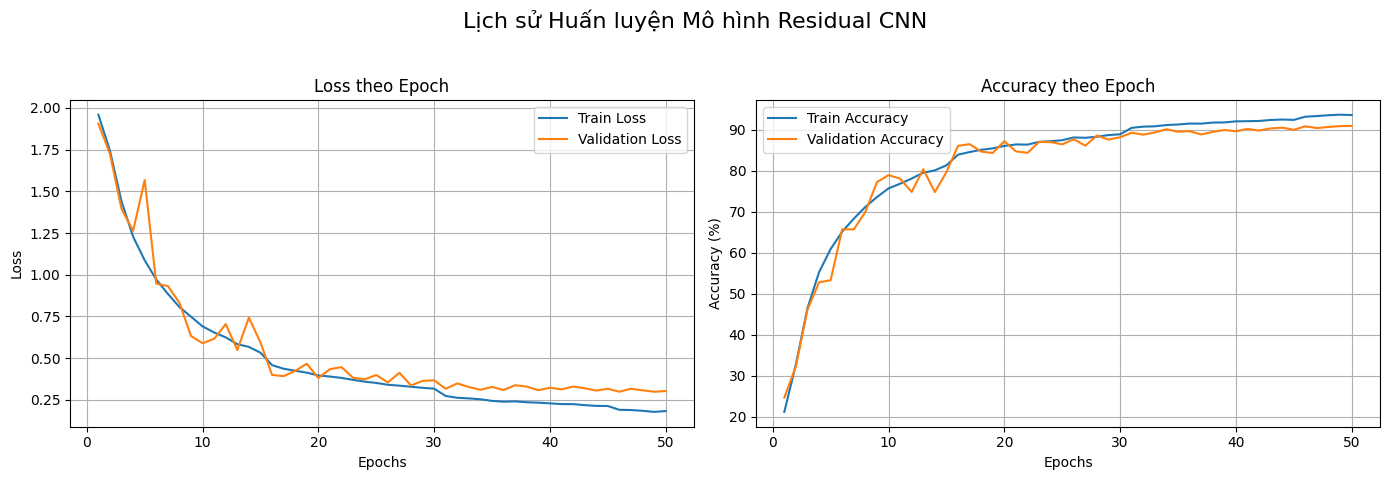

In [29]:
if 'training_history' in locals():
    plot_history(training_history)

In [30]:
## 6.2. Đánh giá Chi tiết (Ma trận Nhầm lẫn)
def detailed_evaluation(model, dataloader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Ma trận nhầm lẫn
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Ma trận Nhầm lẫn (Confusion Matrix)')
    plt.xlabel('Dự đoán (Predicted Label)')
    plt.ylabel('Thực tế (True Label)')
    plt.show()

    # Báo cáo phân loại (Precision, Recall, F1-Score)
    print("\n--- Báo cáo Phân loại (Classification Report) ---")
    print(classification_report(all_labels, all_preds, target_names=classes))



In [35]:
    test_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((75, 75)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    # --- Dataset & Dataloader ---
    test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

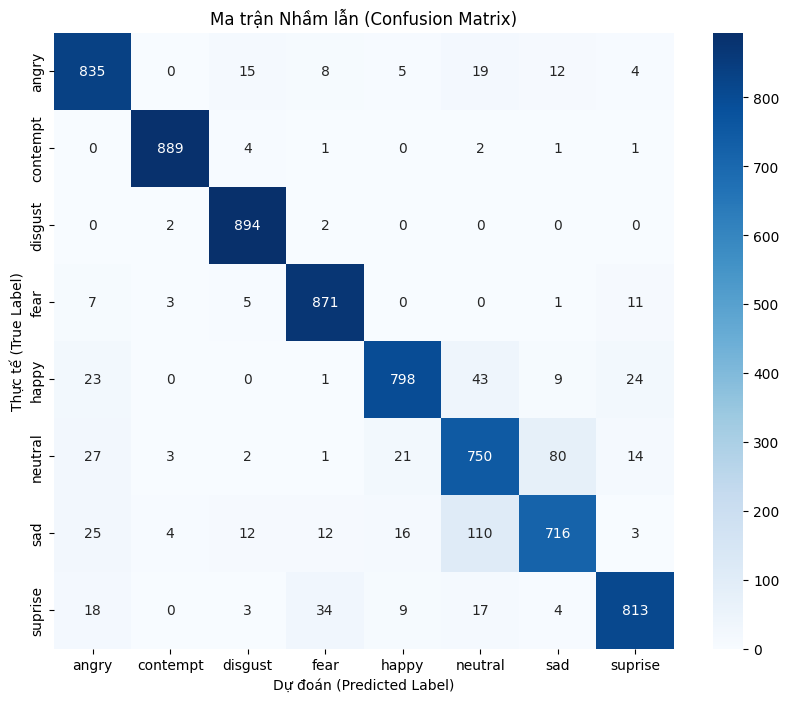


--- Báo cáo Phân loại (Classification Report) ---
              precision    recall  f1-score   support

       angry       0.89      0.93      0.91       898
    contempt       0.99      0.99      0.99       898
     disgust       0.96      1.00      0.98       898
        fear       0.94      0.97      0.95       898
       happy       0.94      0.89      0.91       898
     neutral       0.80      0.84      0.82       898
         sad       0.87      0.80      0.83       898
     suprise       0.93      0.91      0.92       898

    accuracy                           0.91      7184
   macro avg       0.91      0.91      0.91      7184
weighted avg       0.91      0.91      0.91      7184



In [36]:
model = FaceEmotionCNN(num_classes=NUM_CLASSES, in_channels=1).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'final_model.pth'), map_location=DEVICE))
detailed_evaluation(best_model, test_loader, DEVICE, CLASSES)